# K-Nearest Neighbors (KNN)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/ml-mastery/blob/main/02_ml_concepts/knn.ipynb)

---

## Table of Contents
1. [Concept Overview](#1-concept-overview)
2. [Math Intuition](#2-math-intuition)
   - 2.1 The Core Idea — Lazy Learning
   - 2.2 Distance Metrics
   - 2.3 KNN for Classification — Majority Vote
   - 2.4 KNN for Regression — Averaging
   - 2.5 Weighted KNN
   - 2.6 Choosing K — the Bias-Variance Tradeoff
   - 2.7 The Curse of Dimensionality
3. [Visual Intuition](#3-visual-intuition)
4. [Code from Scratch](#4-code-from-scratch)
5. [Sklearn Implementation](#5-sklearn-implementation)
6. [Common Mistakes](#6-common-mistakes)
7. [Exercises](#7-exercises)


## 1. Concept Overview

KNN is a **non-parametric, lazy learning** algorithm. It makes no assumptions about the underlying data distribution and does not learn a model during training. Instead, it memorizes the entire training set and at prediction time finds the $K$ closest training points to the query point, then votes (classification) or averages (regression).

**The core idea:** Points that are close to each other in feature space are likely to have the same label.

**When to use it:**
- Small to medium datasets (large datasets make prediction slow)
- Non-linear decision boundaries without kernel tricks
- When you need a simple, interpretable baseline
- Anomaly detection (points far from all neighbors are outliers)
- Recommendation systems (find similar items/users)

**Strengths:** No training phase, naturally handles multi-class, adapts to local structure, non-parametric

**Weaknesses:** Slow prediction on large data $O(nd)$ per query, sensitive to irrelevant features, requires feature scaling, high memory usage (stores all training data), suffers from curse of dimensionality


## 2. Math Intuition

### 2.1 The Core Idea — Lazy Learning

Unlike parametric models (linear regression, SVM) that learn a fixed set of parameters during training, KNN is **lazy** — it defers all computation to prediction time. There is no explicit training step.

**Training:** Store all $(\mathbf{x}_i, y_i)$ pairs. Cost: $O(1)$ time, $O(nd)$ space.

**Prediction for query $\mathbf{x}_q$:**
1. Compute distance from $\mathbf{x}_q$ to every training point: $O(nd)$
2. Sort distances and find the $K$ smallest: $O(n \log n)$
3. Aggregate the $K$ labels: $O(K)$

Total prediction cost: $O(nd)$ per query — expensive for large $n$.

---

### 2.2 Distance Metrics

The choice of distance metric fundamentally changes what "nearest" means.

**Minkowski distance** (general family):

$$d_p(\mathbf{x}, \mathbf{z}) = \left(\sum_{j=1}^{d} |x_j - z_j|^p \right)^{1/p}$$

Special cases:
- $p = 1$: **Manhattan distance** (L1) — sum of absolute differences
$$d_1(\mathbf{x}, \mathbf{z}) = \sum_{j=1}^{d} |x_j - z_j|$$

- $p = 2$: **Euclidean distance** (L2) — straight-line distance
$$d_2(\mathbf{x}, \mathbf{z}) = \sqrt{\sum_{j=1}^{d} (x_j - z_j)^2}$$

- $p \to \infty$: **Chebyshev distance** (L∞) — maximum absolute difference
$$d_\infty(\mathbf{x}, \mathbf{z}) = \max_j |x_j - z_j|$$

**Other metrics:**
- **Hamming distance** — fraction of positions that differ (for binary/categorical features)
- **Cosine similarity** — angle between vectors (for text, high-dimensional sparse data):
$$\cos(\mathbf{x}, \mathbf{z}) = \frac{\mathbf{x}^T \mathbf{z}}{\|\mathbf{x}\| \|\mathbf{z}\|}$$

**Why scaling matters:** If feature 1 ranges from 0–1 and feature 2 ranges from 0–1000, Euclidean distance is almost entirely determined by feature 2. Standardizing features before KNN is **mandatory**.

---

### 2.3 KNN for Classification — Majority Vote

Given query $\mathbf{x}_q$, find the $K$ nearest neighbors $\mathcal{N}_K(\mathbf{x}_q)$ and predict:

$$\hat{y} = \arg\max_{c} \sum_{i \in \mathcal{N}_K(\mathbf{x}_q)} \mathbb{1}[y_i = c]$$

**Probability estimate:**

$$P(y = c \mid \mathbf{x}_q) = \frac{1}{K} \sum_{i \in \mathcal{N}_K(\mathbf{x}_q)} \mathbb{1}[y_i = c]$$

---

### 2.4 KNN for Regression — Averaging

$$\hat{y} = \frac{1}{K} \sum_{i \in \mathcal{N}_K(\mathbf{x}_q)} y_i$$

The prediction is simply the mean of the $K$ nearest neighbors' target values. Increasing $K$ smooths the prediction surface.

---

### 2.5 Weighted KNN

Instead of giving all $K$ neighbors equal weight, weight by inverse distance — closer neighbors have more influence:

$$\hat{y} = \frac{\sum_{i \in \mathcal{N}_K} w_i y_i}{\sum_{i \in \mathcal{N}_K} w_i} \quad \text{where} \quad w_i = \frac{1}{d(\mathbf{x}_q, \mathbf{x}_i) + \epsilon}$$

This handles the case where two neighbors are very close but one is much closer than the other — the closer one should dominate.

---

### 2.6 Choosing K — the Bias-Variance Tradeoff

| Small $K$ | Large $K$ |
|---|---|
| Low bias — fits local structure closely | High bias — ignores local structure |
| High variance — sensitive to noise | Low variance — smooth decision boundary |
| Risk of overfitting | Risk of underfitting |
| $K=1$: memorizes training data | $K=n$: always predicts majority class |

**Rules of thumb:**
- Start with $K = \sqrt{n}$ where $n$ is training set size
- Always try odd $K$ for binary classification (avoids ties)
- Use cross-validation to find the optimal $K$

The optimal $K$ minimizes the cross-validation error, balancing the bias-variance tradeoff.

---

### 2.7 The Curse of Dimensionality

In high dimensions, all points become approximately equidistant from each other — the concept of "nearest neighbor" loses meaning.

**Formally:** In $d$ dimensions, to capture a fraction $r$ of the data volume in a hypercube, the side length required is:

$$l = r^{1/d}$$

For $r = 0.01$ (1% of data): in $d=1$, $l = 0.01$. In $d=10$, $l = 0.631$. In $d=100$, $l = 0.955$.

In 100 dimensions, you need to cover 95.5% of the feature range in every dimension just to find 1% of the data. The nearest neighbors are no longer truly "near" — they can be almost anywhere.

**Consequences for KNN:**
- Accuracy degrades as $d$ increases
- Need exponentially more data to maintain the same density
- Feature selection and dimensionality reduction (PCA) become critical before KNN


## 3. Visual Intuition

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)


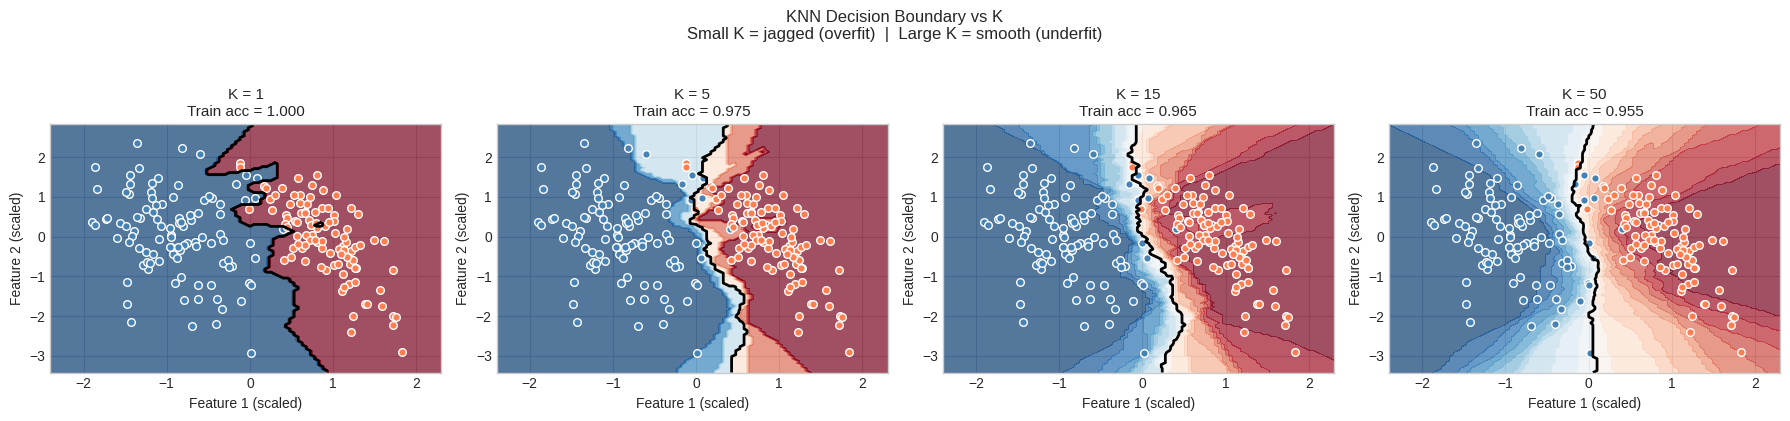

In [23]:
# ── Plot 1: KNN decision boundary for different K values ─────────────────────
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

X_vis, y_vis = make_classification(n_samples=200, n_features=2, n_redundant=0,
                                    n_informative=2, random_state=5,
                                    n_clusters_per_class=1, class_sep=0.9)

scaler = StandardScaler()
X_vis_s = scaler.fit_transform(X_vis)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
K_vals = [1, 5, 15, 50]

h = 0.05
x_min, x_max = X_vis_s[:,0].min()-0.5, X_vis_s[:,0].max()+0.5
y_min, y_max = X_vis_s[:,1].min()-0.5, X_vis_s[:,1].max()+0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

for ax, K in zip(axes, K_vals):
    knn = KNeighborsClassifier(n_neighbors=K)
    knn.fit(X_vis_s, y_vis)

    Z = knn.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.7)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    ax.scatter(X_vis_s[y_vis==0,0], X_vis_s[y_vis==0,1],
               c='steelblue', edgecolors='white', s=30)
    ax.scatter(X_vis_s[y_vis==1,0], X_vis_s[y_vis==1,1],
               c='coral', edgecolors='white', s=30)

    tr_acc = knn.score(X_vis_s, y_vis)
    ax.set_title(f"K = {K}\nTrain acc = {tr_acc:.3f}", fontsize=11)
    ax.set_xlabel("Feature 1 (scaled)")
    ax.set_ylabel("Feature 2 (scaled)")

plt.suptitle("KNN Decision Boundary vs K\nSmall K = jagged (overfit)  |  Large K = smooth (underfit)",
             fontsize=12, y=1.04)
plt.tight_layout()
plt.show()


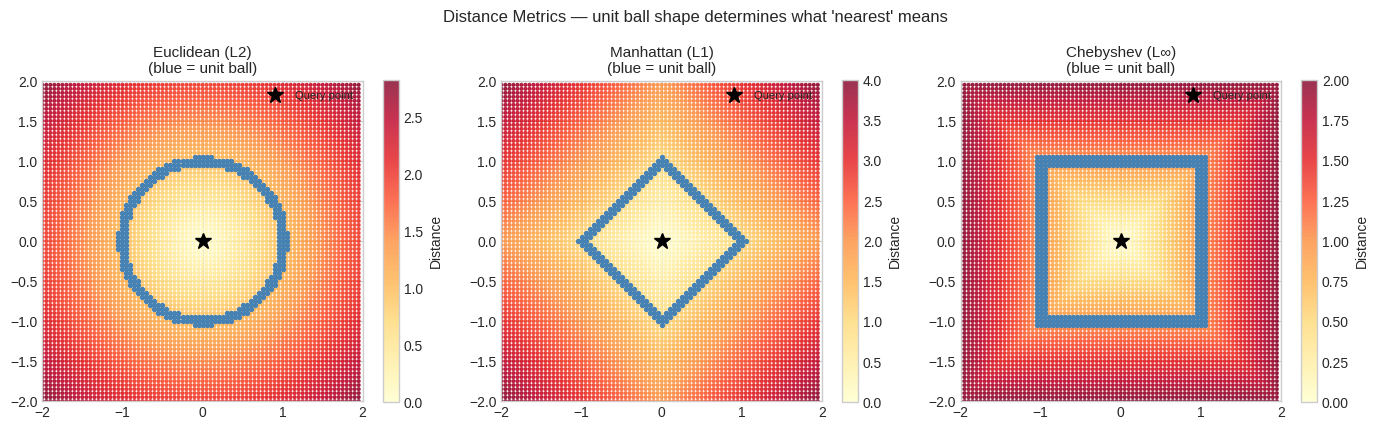

In [24]:
# ── Plot 2: Distance metrics comparison ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

query = np.array([0.0, 0.0])
metrics = [
    ('Euclidean (L2)', lambda x: np.sqrt(np.sum(x**2, axis=1))),
    ('Manhattan (L1)', lambda x: np.sum(np.abs(x), axis=1)),
    ('Chebyshev (L∞)', lambda x: np.max(np.abs(x), axis=1)),
]

# Draw "unit ball" for each metric (all points at distance = 1)
theta = np.linspace(0, 2*np.pi, 1000)

for ax, (name, dist_fn) in zip(axes, metrics):
    # Generate a grid and color by distance
    grid = np.mgrid[-2:2:0.05, -2:2:0.05].reshape(2,-1).T
    distances = dist_fn(grid - query)

    sc = ax.scatter(grid[:,0], grid[:,1], c=distances,
                    cmap='YlOrRd', s=4, alpha=0.8)
    plt.colorbar(sc, ax=ax, label='Distance')

    # Draw unit ball (isocurve at distance=1)
    iso_pts = grid[np.abs(distances - 1.0) < 0.06]
    ax.scatter(iso_pts[:,0], iso_pts[:,1], c='steelblue', s=8, zorder=5)

    ax.plot(0, 0, 'k*', markersize=12, zorder=6, label='Query point')
    ax.set_title(f"{name}\n(blue = unit ball)", fontsize=11)
    ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
    ax.set_aspect('equal')
    ax.legend(fontsize=8)

plt.suptitle("Distance Metrics — unit ball shape determines what 'nearest' means",
             fontsize=12, y=1.04)
plt.tight_layout()
plt.show()


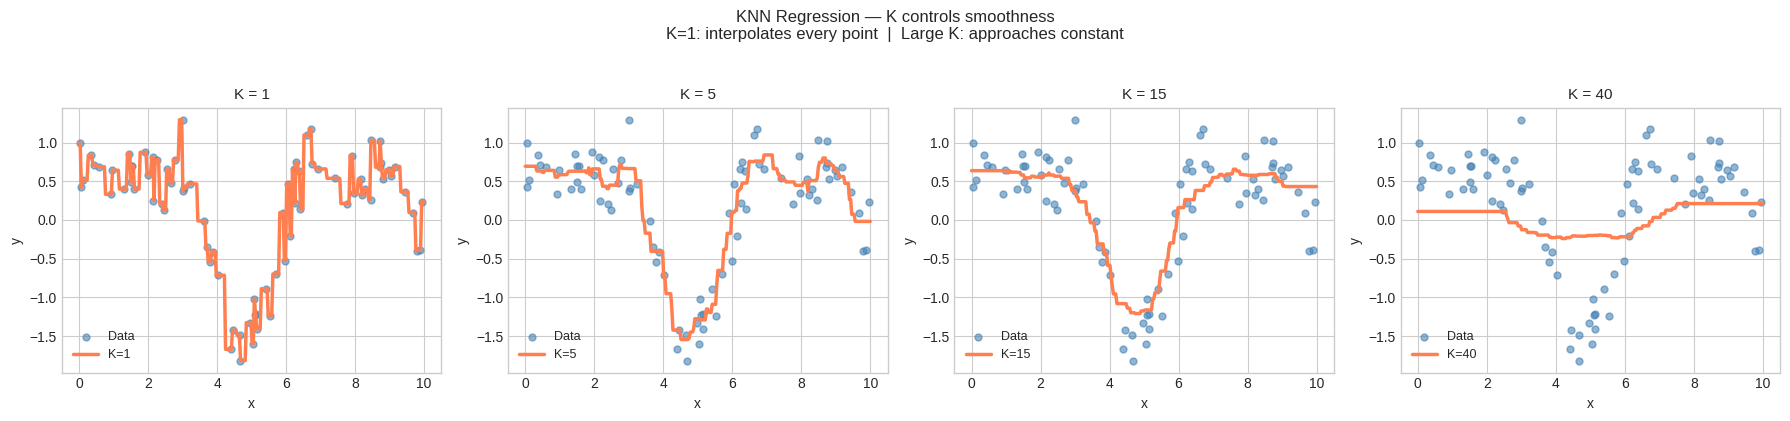

In [25]:
# ── Plot 3: KNN regression — effect of K on smoothing ────────────────────────
from sklearn.neighbors import KNeighborsRegressor

rng2 = np.random.default_rng(7)
X_reg = np.sort(rng2.uniform(0, 10, 80))
y_reg = np.sin(X_reg) + 0.5 * np.cos(2 * X_reg) + rng2.normal(0, 0.3, 80)

X_plot = np.linspace(0, 10, 300).reshape(-1, 1)
X_reg_2d = X_reg.reshape(-1, 1)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
K_reg = [1, 5, 15, 40]

for ax, K in zip(axes, K_reg):
    knn_r = KNeighborsRegressor(n_neighbors=K, weights='uniform')
    knn_r.fit(X_reg_2d, y_reg)
    y_plot = knn_r.predict(X_plot)

    ax.scatter(X_reg, y_reg, color='steelblue', s=25, alpha=0.6, label='Data')
    ax.plot(X_plot, y_plot, color='coral', linewidth=2.5, label=f'K={K}')
    ax.set_title(f"K = {K}", fontsize=11)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.legend(fontsize=9)

plt.suptitle("KNN Regression — K controls smoothness\nK=1: interpolates every point  |  Large K: approaches constant",
             fontsize=12, y=1.04)
plt.tight_layout()
plt.show()


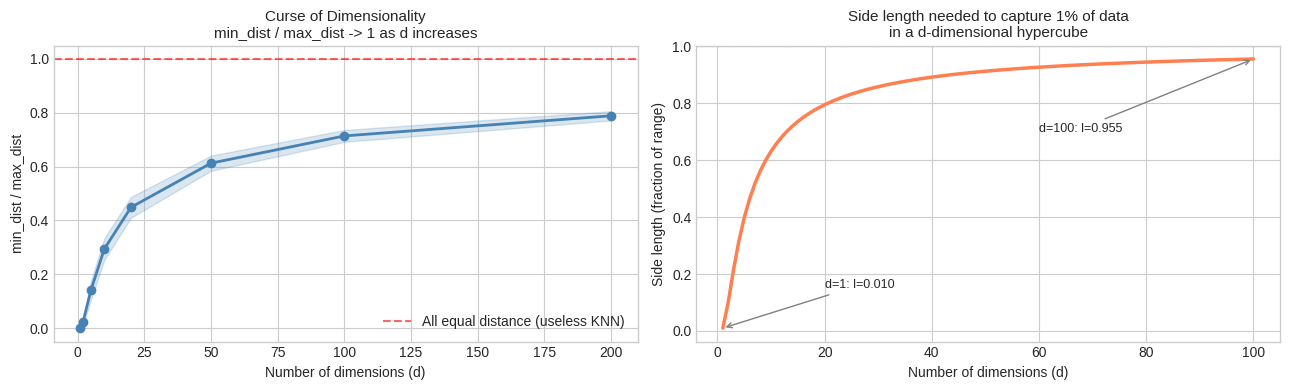

In [26]:
# ── Plot 4: Curse of dimensionality ──────────────────────────────────────────
# As dimensions increase, ratio of nearest/farthest neighbor distance -> 1
# All points become equidistant

dimensions = [1, 2, 5, 10, 20, 50, 100, 200]
n_points   = 500
n_trials   = 100

ratio_means = []
ratio_stds  = []

for d in dimensions:
    ratios = []
    for _ in range(n_trials):
        X_d = rng.uniform(0, 1, (n_points, d))
        query_d = rng.uniform(0, 1, (1, d))
        dists = np.sqrt(((X_d - query_d)**2).sum(axis=1))
        ratios.append(dists.min() / dists.max())
    ratio_means.append(np.mean(ratios))
    ratio_stds.append(np.std(ratios))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(dimensions, ratio_means, 'o-', color='steelblue', linewidth=2)
axes[0].fill_between(dimensions,
                     np.array(ratio_means) - np.array(ratio_stds),
                     np.array(ratio_means) + np.array(ratio_stds),
                     alpha=0.2, color='steelblue')
axes[0].set_title("Curse of Dimensionality\nmin_dist / max_dist -> 1 as d increases", fontsize=11)
axes[0].set_xlabel("Number of dimensions (d)")
axes[0].set_ylabel("min_dist / max_dist")
axes[0].axhline(1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.6,
                label='All equal distance (useless KNN)')
axes[0].legend()

# Fraction of data needed to capture 1% volume
r = 0.01
dims_c = np.arange(1, 101)
l_needed = r ** (1.0 / dims_c)
axes[1].plot(dims_c, l_needed, color='coral', linewidth=2.5)
axes[1].set_title("Side length needed to capture 1% of data\nin a d-dimensional hypercube", fontsize=11)
axes[1].set_xlabel("Number of dimensions (d)")
axes[1].set_ylabel("Side length (fraction of range)")
axes[1].axhline(1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
axes[1].annotate(f'd=1: l={0.01**(1/1):.3f}', xy=(1, 0.01), xytext=(20, 0.15),
                 arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)
axes[1].annotate(f'd=100: l={0.01**(1/100):.3f}', xy=(100, 0.01**(1/100)),
                 xytext=(60, 0.7), arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)

plt.tight_layout()
plt.show()


## 4. Code from Scratch

In [6]:
class KNNScratch:
    """
    K-Nearest Neighbors for both classification and regression.

    Classification: majority vote among K nearest neighbors
    Regression:     mean (or weighted mean) of K nearest neighbors

    Distance: Minkowski with parameter p
      p=1 -> Manhattan, p=2 -> Euclidean (default)
    """

    def __init__(self, n_neighbors=5, task='classification',
                 weights='uniform', p=2):
        self.K       = n_neighbors
        self.task    = task       # 'classification' or 'regression'
        self.weights = weights    # 'uniform' or 'distance'
        self.p       = p          # Minkowski power
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """KNN has no training — just store the data."""
        self.X_train = np.array(X, dtype=float)
        self.y_train = np.array(y)
        self.classes_ = np.unique(y) if self.task == 'classification' else None
        return self

    def _minkowski(self, x1, X2):
        """Compute Minkowski distance from x1 to every row of X2."""
        diff = np.abs(X2 - x1)
        return (diff ** self.p).sum(axis=1) ** (1.0 / self.p)

    def _predict_one(self, x):
        # Step 1: compute distances to all training points
        distances = self._minkowski(x, self.X_train)

        # Step 2: find K nearest indices
        k_idx = np.argsort(distances)[:self.K]
        k_dist = distances[k_idx]
        k_labels = self.y_train[k_idx]

        # Step 3: compute weights
        if self.weights == 'distance':
            eps = 1e-10
            w = 1.0 / (k_dist + eps)
            w = w / w.sum()
        else:
            w = np.ones(self.K) / self.K

        # Step 4: aggregate
        if self.task == 'regression':
            return np.sum(w * k_labels)
        else:
            # Weighted majority vote
            class_scores = {c: 0.0 for c in self.classes_}
            for label, weight in zip(k_labels, w):
                class_scores[label] += weight
            return max(class_scores, key=class_scores.get)

    def predict(self, X):
        return np.array([self._predict_one(x) for x in X])

    def predict_proba(self, X):
        """For classification only — returns class probability estimates."""
        proba = []
        for x in X:
            distances = self._minkowski(x, self.X_train)
            k_idx     = np.argsort(distances)[:self.K]
            k_labels  = self.y_train[k_idx]
            probs = np.array([np.mean(k_labels == c) for c in self.classes_])
            proba.append(probs)
        return np.array(proba)

    def score(self, X, y):
        preds = self.predict(X)
        if self.task == 'classification':
            return np.mean(preds == y)
        else:
            ss_res = np.sum((y - preds)**2)
            ss_tot = np.sum((y - np.mean(y))**2)
            return 1 - ss_res / ss_tot


In [7]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Classification test ──────────────────────────────────────────────────────
iris = load_iris()
X_cl, y_cl = iris.data, iris.target

X_tr_cl, X_te_cl, y_tr_cl, y_te_cl = train_test_split(
    X_cl, y_cl, test_size=0.2, random_state=42, stratify=y_cl
)

scaler_cl = StandardScaler()
X_tr_cl_s = scaler_cl.fit_transform(X_tr_cl)
X_te_cl_s = scaler_cl.transform(X_te_cl)

knn_scratch = KNNScratch(n_neighbors=5, task='classification', weights='uniform')
knn_scratch.fit(X_tr_cl_s, y_tr_cl)

print("KNN Classification (Iris dataset):")
print(f"  Train accuracy: {knn_scratch.score(X_tr_cl_s, y_tr_cl):.4f}")
print(f"  Test  accuracy: {knn_scratch.score(X_te_cl_s, y_te_cl):.4f}")


KNN Classification (Iris dataset):
  Train accuracy: 0.9750
  Test  accuracy: 0.9333


KNN Regression:
  Test R²: -5.1439


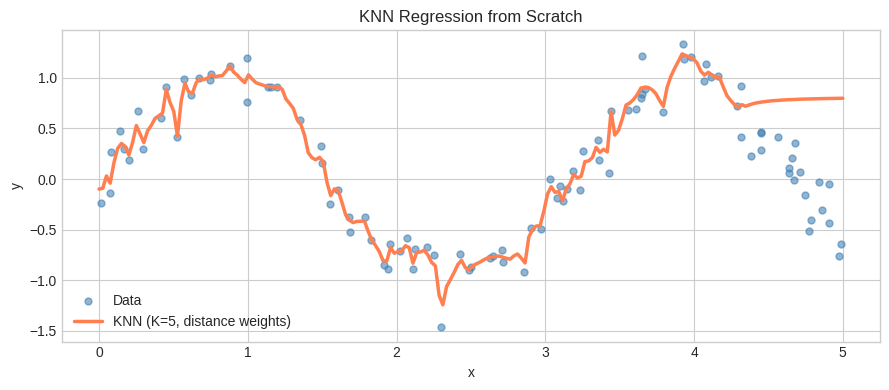

In [8]:
# ── Regression test ──────────────────────────────────────────────────────────
rng3 = np.random.default_rng(0)
X_rg = np.sort(rng3.uniform(0, 5, 100))
y_rg = np.sin(X_rg * 2) + rng3.normal(0, 0.2, 100)

X_tr_rg = X_rg[:80].reshape(-1, 1)
X_te_rg = X_rg[80:].reshape(-1, 1)
y_tr_rg = y_rg[:80]
y_te_rg = y_rg[80:]

knn_reg = KNNScratch(n_neighbors=5, task='regression', weights='distance')
knn_reg.fit(X_tr_rg, y_tr_rg)

print("KNN Regression:")
print(f"  Test R²: {knn_reg.score(X_te_rg, y_te_rg):.4f}")

# Plot
X_plot = np.linspace(0, 5, 200).reshape(-1, 1)
y_pred_plot = knn_reg.predict(X_plot)

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(X_rg, y_rg, color='steelblue', s=25, alpha=0.6, label='Data')
ax.plot(X_plot, y_pred_plot, color='coral', linewidth=2.5, label='KNN (K=5, distance weights)')
ax.set_title("KNN Regression from Scratch")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend()
plt.tight_layout()
plt.show()


In [9]:
# Verify against sklearn
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

sk_knn = KNeighborsClassifier(n_neighbors=5, weights='uniform', p=2)
sk_knn.fit(X_tr_cl_s, y_tr_cl)
print(f"Sklearn KNN classification test acc: {sk_knn.score(X_te_cl_s, y_te_cl):.4f}")
print("Results should match our scratch implementation.")


Sklearn KNN classification test acc: 0.9333
Results should match our scratch implementation.


## 5. Sklearn Implementation

In [10]:
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import classification_report
import warnings; warnings.filterwarnings('ignore')

pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(
        n_neighbors=5,      # K — most important hyperparameter
        weights='uniform',  # 'uniform' or 'distance'
        metric='euclidean', # 'euclidean', 'manhattan', 'minkowski', 'cosine', etc.
        p=2,                # Minkowski power (2=Euclidean, 1=Manhattan)
        algorithm='auto',   # 'auto', 'ball_tree', 'kd_tree', 'brute'
        n_jobs=-1
    ))
])

pipe_knn.fit(X_tr_cl, y_tr_cl)
print("KNN on Iris:")
print(f"  Train: {pipe_knn.score(X_tr_cl, y_tr_cl):.4f} | Test: {pipe_knn.score(X_te_cl, y_te_cl):.4f}")
print()
print(classification_report(y_te_cl, pipe_knn.predict(X_te_cl),
      target_names=iris.target_names))


KNN on Iris:
  Train: 0.9750 | Test: 0.9333

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



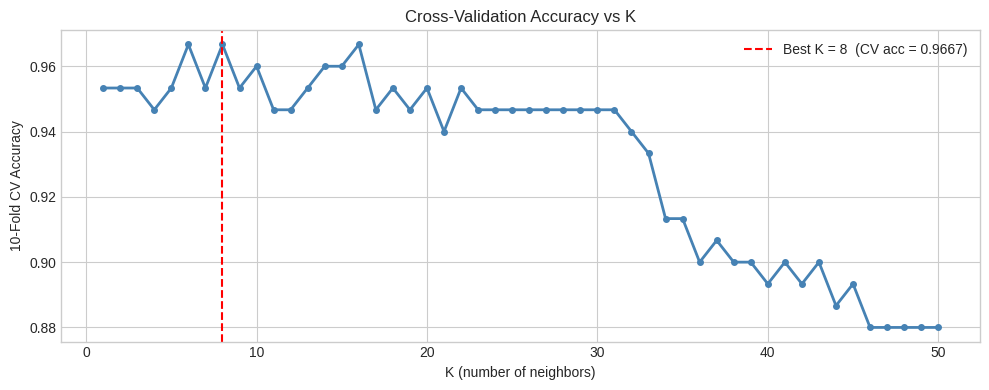

Best K: 8


In [11]:
# Find optimal K using cross-validation
K_range = range(1, 51)
cv_scores = []

for K in K_range:
    pipe_k = Pipeline([
        ('sc',  StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=K, n_jobs=-1))
    ])
    scores = cross_val_score(pipe_k, X_cl, y_cl, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())

best_K = K_range[np.argmax(cv_scores)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(list(K_range), cv_scores, 'o-', color='steelblue', linewidth=2, markersize=4)
ax.axvline(best_K, color='red', linestyle='--', linewidth=1.5,
           label=f'Best K = {best_K}  (CV acc = {max(cv_scores):.4f})')
ax.set_title("Cross-Validation Accuracy vs K")
ax.set_xlabel("K (number of neighbors)")
ax.set_ylabel("10-Fold CV Accuracy")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Best K: {best_K}")


In [12]:
# Compare distance metrics
from sklearn.datasets import load_wine

data_w = load_wine()
X_w, y_w = data_w.data, data_w.target
X_tr_w, X_te_w, y_tr_w, y_te_w = train_test_split(X_w, y_w, test_size=0.2,
                                                     random_state=42, stratify=y_w)

print(f"{'Metric':<15}  {'Weights':<10}  {'K':<4}  {'CV Acc':>8}  {'Test Acc':>10}")

for metric in ['euclidean', 'manhattan', 'chebyshev']:
    for weights in ['uniform', 'distance']:
        pipe_m = Pipeline([
            ('sc',  StandardScaler()),
            ('knn', KNeighborsClassifier(n_neighbors=7, metric=metric,
                                         weights=weights, n_jobs=-1))
        ])
        cv = cross_val_score(pipe_m, X_w, y_w, cv=5, scoring='accuracy').mean()
        pipe_m.fit(X_tr_w, y_tr_w)
        te = pipe_m.score(X_te_w, y_te_w)
        print(f"{metric:<15}  {weights:<10}  {7:<4}  {cv:8.4f}  {te:10.4f}")


Metric           Weights     K       CV Acc    Test Acc
euclidean        uniform     7       0.9665      1.0000
euclidean        distance    7       0.9610      1.0000
manhattan        uniform     7       0.9552      1.0000
manhattan        distance    7       0.9552      1.0000
chebyshev        uniform     7       0.9156      0.9167
chebyshev        distance    7       0.9211      0.8889


In [13]:
# GridSearchCV — tune K, metric, and weights together
param_grid = {
    'knn__n_neighbors': list(range(1, 31, 2)),
    'knn__weights':     ['uniform', 'distance'],
    'knn__metric':      ['euclidean', 'manhattan'],
}

grid = GridSearchCV(
    Pipeline([('sc', StandardScaler()),
              ('knn', KNeighborsClassifier(n_jobs=-1))]),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid.fit(X_tr_w, y_tr_w)

print("Best parameters:", grid.best_params_)
print(f"Best CV accuracy:  {grid.best_score_:.4f}")
print(f"Test  accuracy:    {grid.best_estimator_.score(X_te_w, y_te_w):.4f}")


Best parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 9, 'knn__weights': 'uniform'}
Best CV accuracy:  0.9862
Test  accuracy:    1.0000


## 6. Common Mistakes

In [14]:
# MISTAKE 1: Forgetting to scale features — the most common KNN error
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification

X_ms, y_ms = make_classification(n_samples=300, n_features=2, n_redundant=0,
                                   random_state=3, n_clusters_per_class=1)

# Introduce drastic scale difference
X_ms_unscaled = X_ms.copy()
X_ms_unscaled[:, 1] *= 100   # feature 2 now dominates distances

X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(X_ms_unscaled, y_ms,
                                                    test_size=0.3, random_state=0)

# Without scaling
knn_ns = KNeighborsClassifier(n_neighbors=5)
knn_ns.fit(X_tr_m, y_tr_m)

# With scaling
pipe_scaled = Pipeline([('sc', StandardScaler()),
                         ('knn', KNeighborsClassifier(n_neighbors=5))])
pipe_scaled.fit(X_tr_m, y_tr_m)

print("Effect of feature scaling on KNN:")
print(f"  Without scaling: test acc = {knn_ns.score(X_te_m, y_te_m):.4f}")
print(f"  With    scaling: test acc = {pipe_scaled.score(X_te_m, y_te_m):.4f}")
print("\nAlways use StandardScaler (or MinMaxScaler) before KNN.")


Effect of feature scaling on KNN:
  Without scaling: test acc = 0.5778
  With    scaling: test acc = 0.9889

Always use StandardScaler (or MinMaxScaler) before KNN.


In [15]:
# MISTAKE 2: Using even K for binary classification causes ties
# With K=2, it's possible that 1 neighbor is class 0 and 1 is class 1 — tie!
# sklearn breaks ties arbitrarily. Use odd K to avoid this.

rng4 = np.random.default_rng(123)
X_tie = rng4.normal(0, 1, (100, 2))
y_tie = (X_tie[:,0] + X_tie[:,1] > 0).astype(int)

print("Accuracy with even vs odd K (binary classification):")
print(f"{'K':<5}  {'Test acc':>10}  {'Note':>20}")
for K in [2, 3, 4, 5, 6, 7]:
    pipe_t = Pipeline([('sc', StandardScaler()),
                        ('knn', KNeighborsClassifier(n_neighbors=K))])
    scores = cross_val_score(pipe_t, X_tie, y_tie, cv=5)
    note = '<-- risk of ties' if K % 2 == 0 else ''
    print(f"{K:<5}  {scores.mean():10.4f}  {note}")

print("\nPrefer odd K for binary classification to avoid tied votes.")


Accuracy with even vs odd K (binary classification):
K        Test acc                  Note
2          0.9500  <-- risk of ties
3          0.9400  
4          0.9600  <-- risk of ties
5          0.9300  
6          0.9400  <-- risk of ties
7          0.9500  

Prefer odd K for binary classification to avoid tied votes.


In [16]:
# MISTAKE 3: Using KNN on large datasets without approximate methods
# Brute force KNN is O(nd) per query. Use KD-Tree or Ball-Tree for speed.

import time
from sklearn.neighbors import KNeighborsClassifier

X_large = rng.normal(0, 1, (5000, 10))
y_large = (X_large[:,0] > 0).astype(int)
X_query = rng.normal(0, 1, (500, 10))

print(f"{'Algorithm':<12}  {'Fit time':>10}  {'Query time':>12}")
for algo in ['brute', 'kd_tree', 'ball_tree']:
    knn_a = KNeighborsClassifier(n_neighbors=5, algorithm=algo)
    t0 = time.time(); knn_a.fit(X_large, y_large); t_fit = time.time() - t0
    t0 = time.time(); knn_a.predict(X_query);       t_q   = time.time() - t0
    print(f"{algo:<12}  {t_fit:10.4f}s  {t_q:12.4f}s")

print("\nKD-Tree and Ball-Tree are much faster for low-to-moderate dimensions.")
print("For very high dimensions (d > ~20), brute force is often competitive.")


Algorithm       Fit time    Query time
brute             0.0018s        0.0157s
kd_tree           0.0063s        0.0457s
ball_tree         0.0050s        0.0408s

KD-Tree and Ball-Tree are much faster for low-to-moderate dimensions.
For very high dimensions (d > ~20), brute force is often competitive.


## 7. Exercises

**Exercise 1:** Implement all three Minkowski distance variants (L1, L2, L∞) manually and verify they give the same results as `scipy.spatial.distance` for a pair of vectors.


In [17]:
# Your code here


In [18]:
# Solution
from scipy.spatial.distance import cityblock, euclidean, chebyshev

a = np.array([1.0, 3.0, 5.0, 2.0])
b = np.array([4.0, 1.0, 3.0, 6.0])

def l1(x, y):  return np.sum(np.abs(x - y))
def l2(x, y):  return np.sqrt(np.sum((x - y)**2))
def linf(x, y): return np.max(np.abs(x - y))

print(f"{'Metric':<10}  {'Scratch':>12}  {'Scipy':>12}  {'Match':>8}")
print(f"{'L1':<10}  {l1(a,b):12.6f}  {cityblock(a,b):12.6f}  {np.isclose(l1(a,b), cityblock(a,b))!s:>8}")
print(f"{'L2':<10}  {l2(a,b):12.6f}  {euclidean(a,b):12.6f}  {np.isclose(l2(a,b), euclidean(a,b))!s:>8}")
print(f"{'L-inf':<10}  {linf(a,b):12.6f}  {chebyshev(a,b):12.6f}  {np.isclose(linf(a,b), chebyshev(a,b))!s:>8}")


Metric           Scratch         Scipy     Match
L1             11.000000     11.000000      True
L2              5.744563      5.744563      True
L-inf           4.000000      4.000000      True


**Exercise 2:** Add a `predict_proba` method to `KNNScratch` using both uniform and distance weights. On the Iris test set, compare the calibration of uniform vs distance-weighted probabilities using a calibration curve.


In [19]:
# Your code here


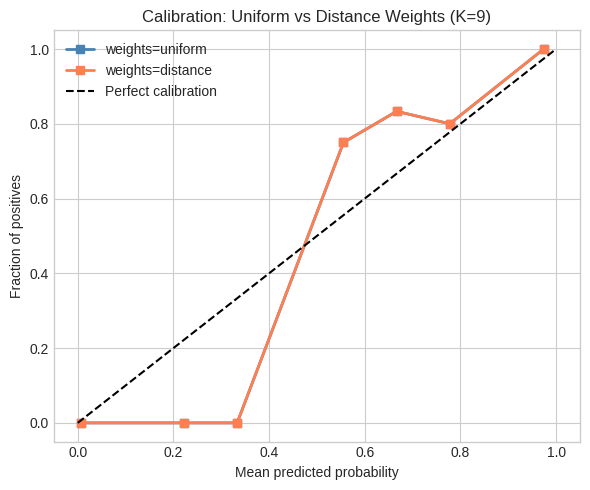

In [20]:
# Solution (predict_proba is already in KNNScratch — compare weights)
from sklearn.calibration import calibration_curve

# Binary version for calibration curve
from sklearn.datasets import load_breast_cancer
data_bc = load_breast_cancer()
X_bc, y_bc = data_bc.data, data_bc.target
X_tr_bc, X_te_bc, y_tr_bc, y_te_bc = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc)

sc_bc = StandardScaler()
X_tr_bc_s = sc_bc.fit_transform(X_tr_bc)
X_te_bc_s = sc_bc.transform(X_te_bc)

fig, ax = plt.subplots(figsize=(6, 5))
for weights, color in [('uniform','steelblue'), ('distance','coral')]:
    knn_c = KNNScratch(n_neighbors=9, task='classification', weights=weights)
    knn_c.fit(X_tr_bc_s, y_tr_bc)
    proba = knn_c.predict_proba(X_te_bc_s)[:,1]
    pt, pp = calibration_curve(y_te_bc, proba, n_bins=8)
    ax.plot(pp, pt, 's-', color=color, linewidth=2, label=f'weights={weights}')

ax.plot([0,1],[0,1],'k--',linewidth=1.5, label='Perfect calibration')
ax.set_title("Calibration: Uniform vs Distance Weights (K=9)")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.legend()
plt.tight_layout()
plt.show()


**Exercise 3:** Demonstrate the curse of dimensionality empirically.
Train a KNN classifier on datasets with 2, 5, 10, 20, 50, and 100 features (keeping the number of samples fixed at 500). Plot test accuracy vs number of dimensions. Then repeat the experiment with 5000 samples. What do you observe?


In [21]:
# Your code here


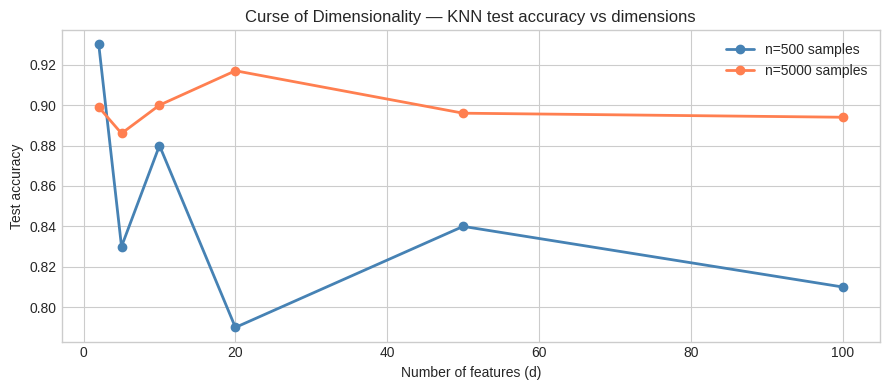

Observations:
1. Accuracy drops as d increases — distances lose meaning.
2. With more samples (5000), the drop is less severe — more data alleviates the curse.
3. Solution: feature selection or PCA before KNN in high dimensions.


In [22]:
# Solution
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier

dim_range = [2, 5, 10, 20, 50, 100]
results = {}

for n_samples in [500, 5000]:
    accs = []
    for d in dim_range:
        X_d, y_d = make_classification(
            n_samples=n_samples, n_features=d,
            n_informative=max(2, d//2), n_redundant=0, random_state=42
        )
        X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(
            X_d, y_d, test_size=0.2, random_state=42)
        pipe_d = Pipeline([('sc', StandardScaler()),
                            ('knn', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))])
        pipe_d.fit(X_tr_d, y_tr_d)
        accs.append(pipe_d.score(X_te_d, y_te_d))
    results[n_samples] = accs

fig, ax = plt.subplots(figsize=(9, 4))
for n_samples, color in [(500,'steelblue'), (5000,'coral')]:
    ax.plot(dim_range, results[n_samples], 'o-', color=color,
            linewidth=2, label=f'n={n_samples} samples')

ax.set_title("Curse of Dimensionality — KNN test accuracy vs dimensions")
ax.set_xlabel("Number of features (d)")
ax.set_ylabel("Test accuracy")
ax.legend()
plt.tight_layout()
plt.show()

print("Observations:")
print("1. Accuracy drops as d increases — distances lose meaning.")
print("2. With more samples (5000), the drop is less severe — more data alleviates the curse.")
print("3. Solution: feature selection or PCA before KNN in high dimensions.")


---

## 👨‍💻 Author

**Himanshu Kumar**

- 🌐 GitHub: [@himanshu231204](https://github.com/himanshu231204)
- 💼 LinkedIn: [himanshu231204](https://www.linkedin.com/in/himanshu231204)
- 🐦 Twitter/X: [@himanshu231204](https://twitter.com/himanshu231204)
- 📧 Email: himanshu231204@gmail.com
